# BÀI TOÁN 1: XÂY DỰNG CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY

## NHIỆM VỤ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

## 1. Import thư viện
Tải các package cần thiết và cấu hình hiển thị đồ thị .

In [24]:
import numpy as np # numerical computation
import pandas as pd # data wrangling
import matplotlib.pyplot as plt # plotting package

# Next line helps with rendering plots
%matplotlib inline

import matplotlib as mpl # add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 # high res figures

import graphviz # to visualize decision trees
from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 2. Nạp và chuẩn bị dữ liệu
Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những đặc trưng (features) không liên quan đến bài toán cần giải quyết.

In [25]:
# Load the data
# Lưu ý: Tên file được thay đổi theo dữ liệu thực tế bạn cung cấp
filename = 'default_of_credit_card_clients.csv'
df = pd.read_csv(filename) 

# Lấy danh sách tên các cột
features_response = df.columns.tolist() 

# Tạo danh sách các cột cần loại bỏ (không phải là feature hoặc biến mục tiêu)
# Lưu ý: Danh sách này dựa trên code mẫu, bạn cần đảm bảo các cột này tồn tại trong file CSV của bạn
items_to_remove = [
    'ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'EDUCATION_CAT', 'graduate school', 'high school', 'none', 'others', 'university'
]

# Lọc danh sách các feature thực sự sẽ dùng
# (Chỉ giữ lại những cột không nằm trong danh sách loại bỏ)
features_response = [item for item in features_response if item not in items_to_remove]

print("Các features được sử dụng:", features_response)

Các features được sử dụng: ['LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


## 3. Chuẩn bị dữ liệu cho tập Train và tập Test
Chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (testing set).

In [26]:
# Split the data into training and testing sets using the same random seed
# Giả sử cột cuối cùng là biến mục tiêu (response variable)
X = df[features_response[:-1]].values
y = df['default payment next month'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24
)

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}")

Kích thước tập train: (24000, 17)
Kích thước tập test: (6000, 17)


## 4. Xây dựng và tối ưu mô hình Cây quyết định (Decision Tree)
Sử dụng GridSearchCV để tìm tham số tối ưu (ví dụ: chiều sâu của cây max_depth) cho mô hình.

In [27]:
# Khởi tạo tham số chiều sâu cần thử nghiệm
params = {'max_depth': [1, 2, 4, 6, 8, 10, 12]}

# Khởi tạo mô hình Decision Tree
dt = DecisionTreeClassifier()

# Thiết lập GridSearchCV
# scoring='roc_auc': sử dụng chỉ số ROC AUC để đánh giá
# cv=4: kiểm chứng chéo 4 lần (4-fold cross-validation)
# return_train_score=True: để đánh giá cả bias và variance
cv = GridSearchCV(
    dt, 
    param_grid=params, 
    scoring='roc_auc', 
    n_jobs=None, 
    refit=True, 
    cv=4, 
    verbose=1, 
    return_train_score=True
)

# Huấn luyện mô hình
cv.fit(X_train, y_train)

# Kết quả tốt nhất
print("Best params:", cv.best_params_)
print("Best score:", cv.best_score_)

Fitting 4 folds for each of 7 candidates, totalling 28 fits
Best params: {'max_depth': 6}
Best score: 0.7439671824278568


## 5. Vẽ biểu đồ đánh giá mô hình Decision Tree
Vẽ biểu đồ thể hiện hiệu suất của mô hình trên tập train và tập test với các độ sâu khác nhau của cây.

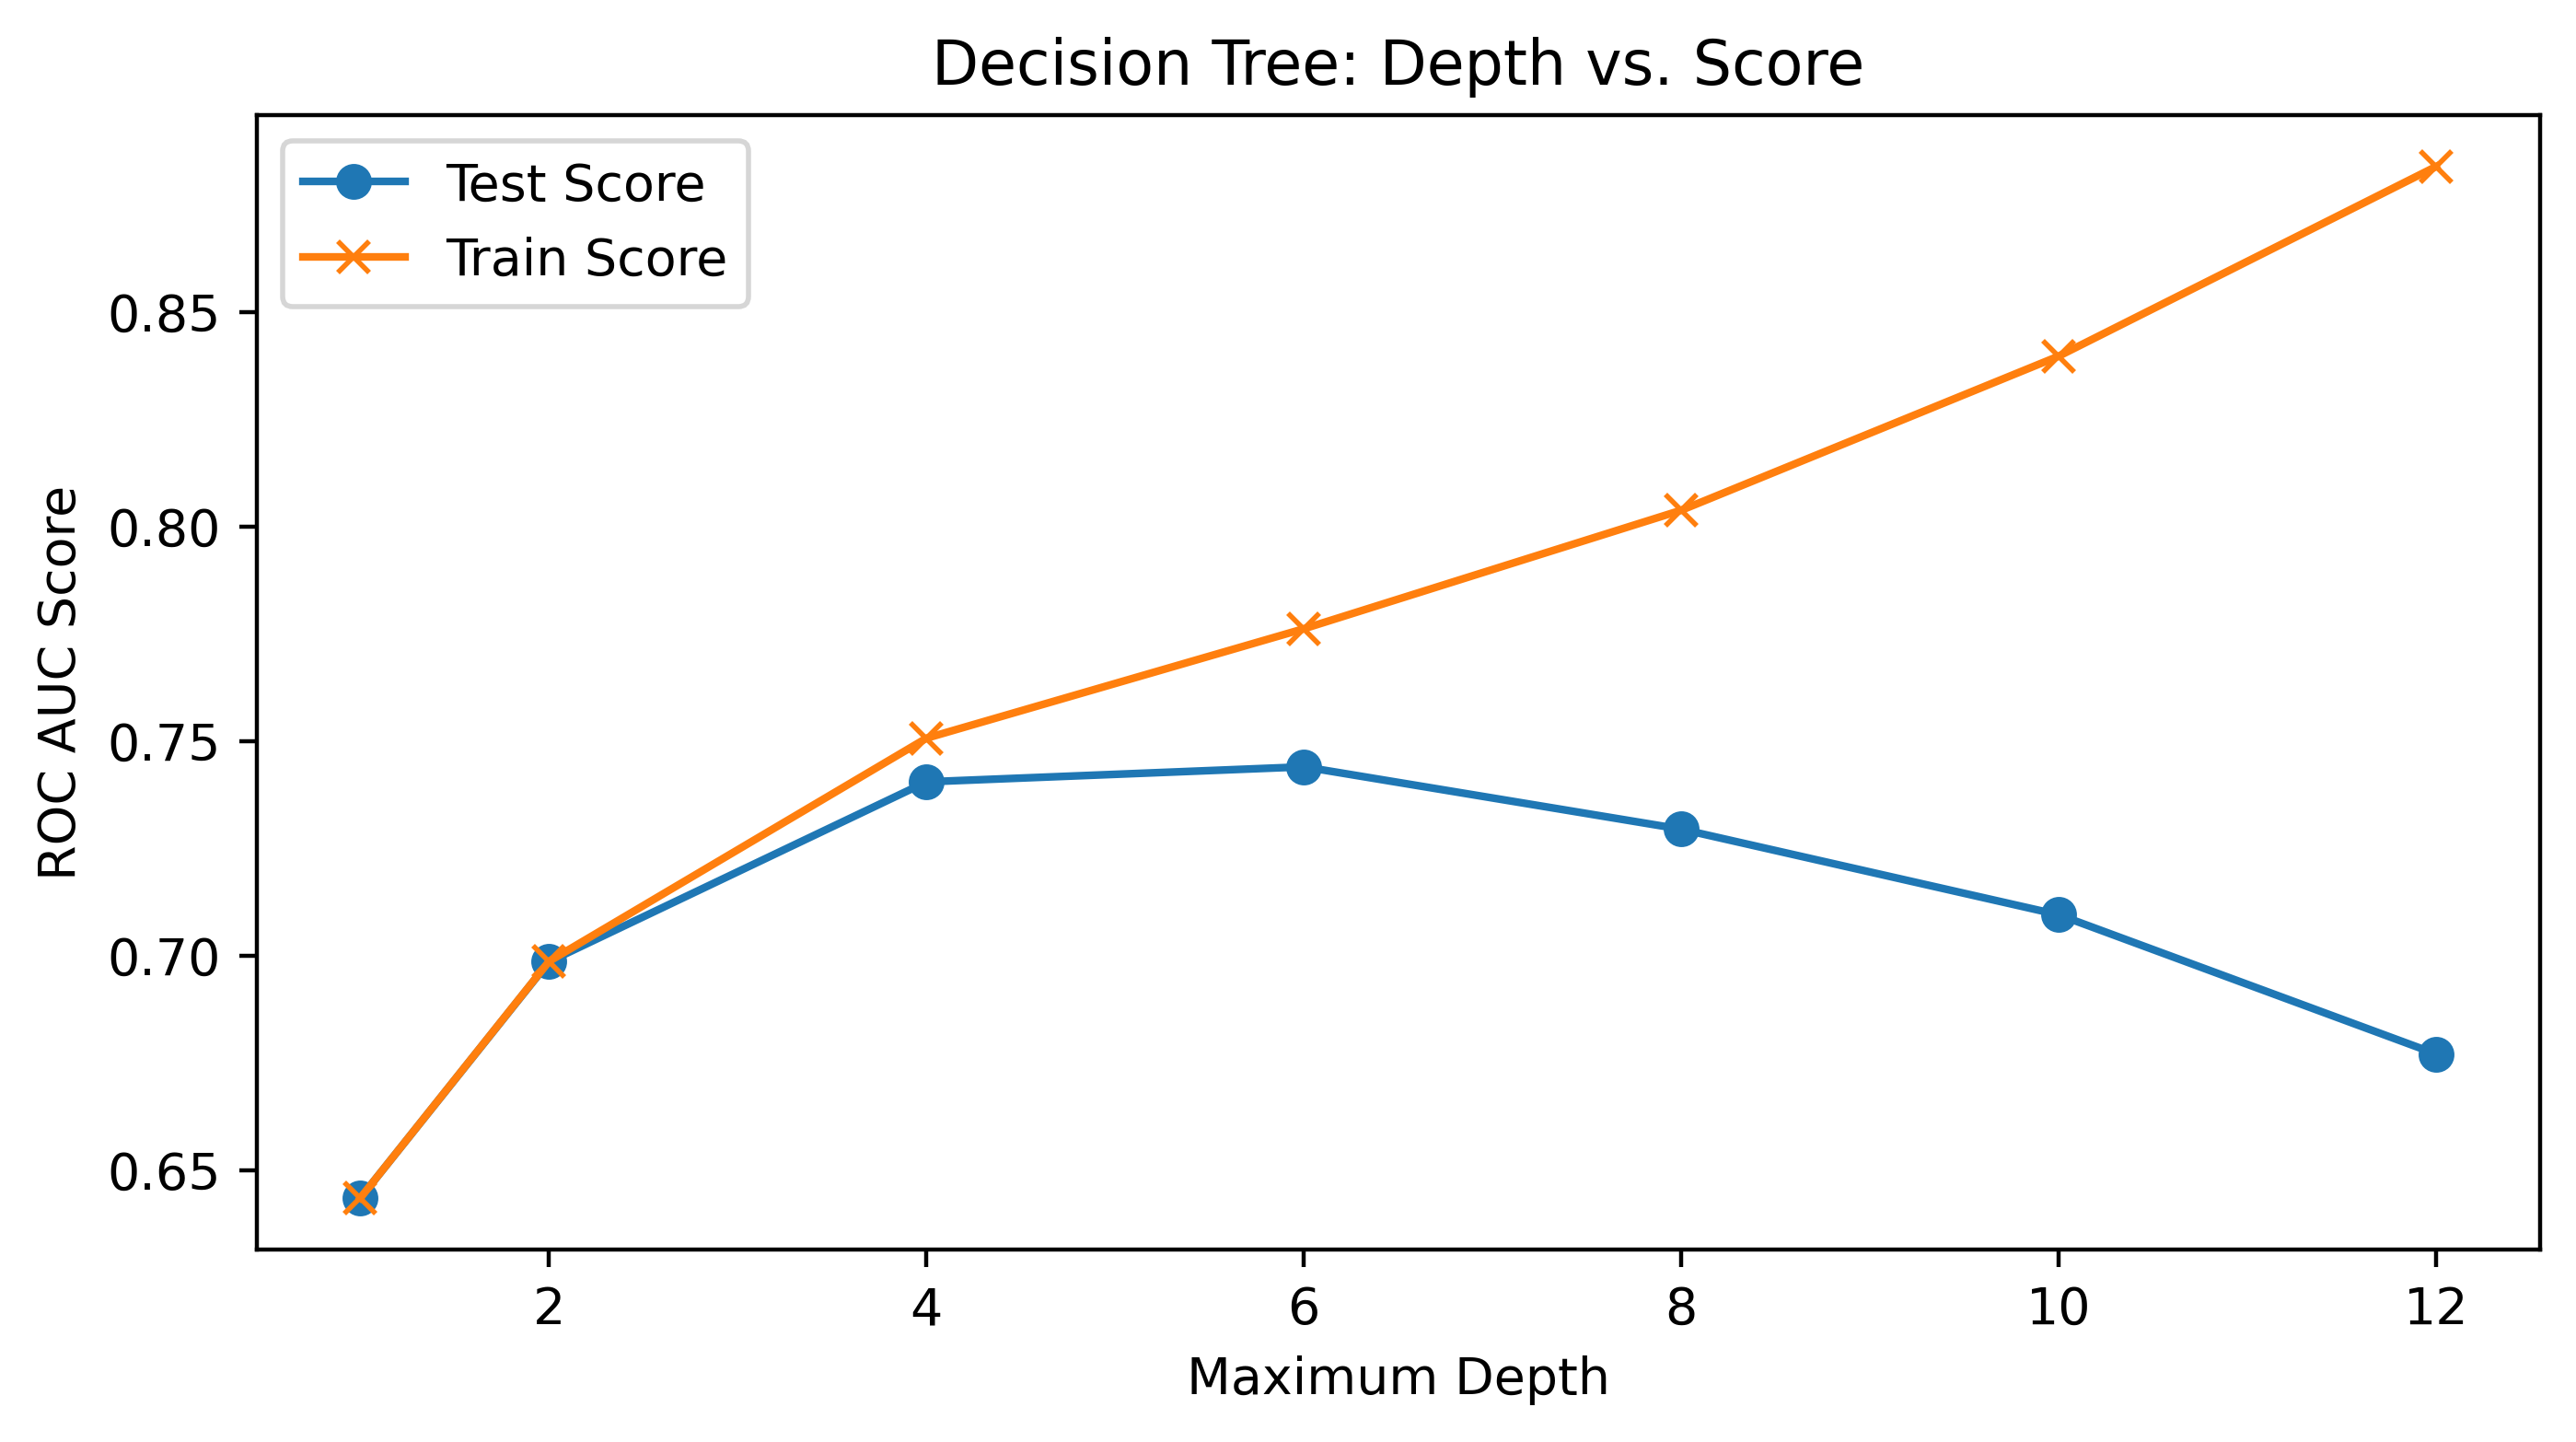

In [28]:
# Chuyển kết quả cv thành DataFrame
cv_results_df = pd.DataFrame(cv.cv_results_)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cv_results_df['param_max_depth'], cv_results_df['mean_test_score'], marker='o', label='Test Score')
ax.plot(cv_results_df['param_max_depth'], cv_results_df['mean_train_score'], marker='x', label='Train Score')
ax.set_xlabel('Maximum Depth')
ax.set_ylabel('ROC AUC Score')
ax.set_title('Decision Tree: Depth vs. Score')
ax.legend()
plt.show()

## 6. Xây dựng mô hình Rừng cây (Random Forest)
Triển khai mô hình Random Forest để cải thiện hiệu suất phân loại. (Phần này trong tài liệu thường nằm ở mục mở rộng hoặc so sánh, dưới đây là đoạn code tương ứng với biểu đồ đánh giá rừng cây).

In [29]:
# Khởi tạo tham số số lượng cây trong rừng
params_rf = {'n_estimators': [10, 50, 100, 200]} 

# Khởi tạo mô hình Random Forest
rf = RandomForestClassifier(random_state=24)

# Thiết lập GridSearchCV cho Random Forest
cv_rf = GridSearchCV(
    rf, 
    param_grid=params_rf, 
    scoring='roc_auc', 
    n_jobs=None, 
    refit=True, 
    cv=4, 
    verbose=1, 
    return_train_score=True
)

# Huấn luyện mô hình
cv_rf.fit(X_train, y_train)

Fitting 4 folds for each of 4 candidates, totalling 16 fits


,estimator,RandomForestC...ndom_state=24)
,param_grid,"{'n_estimators': [10, 50, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


## 7. Vẽ biểu đồ đánh giá mô hình Random Forest
Vẽ biểu đồ đánh giá thời gian huấn luyện và điểm số của mô hình rừng cây với các tham số số lượng cây khác nhau.

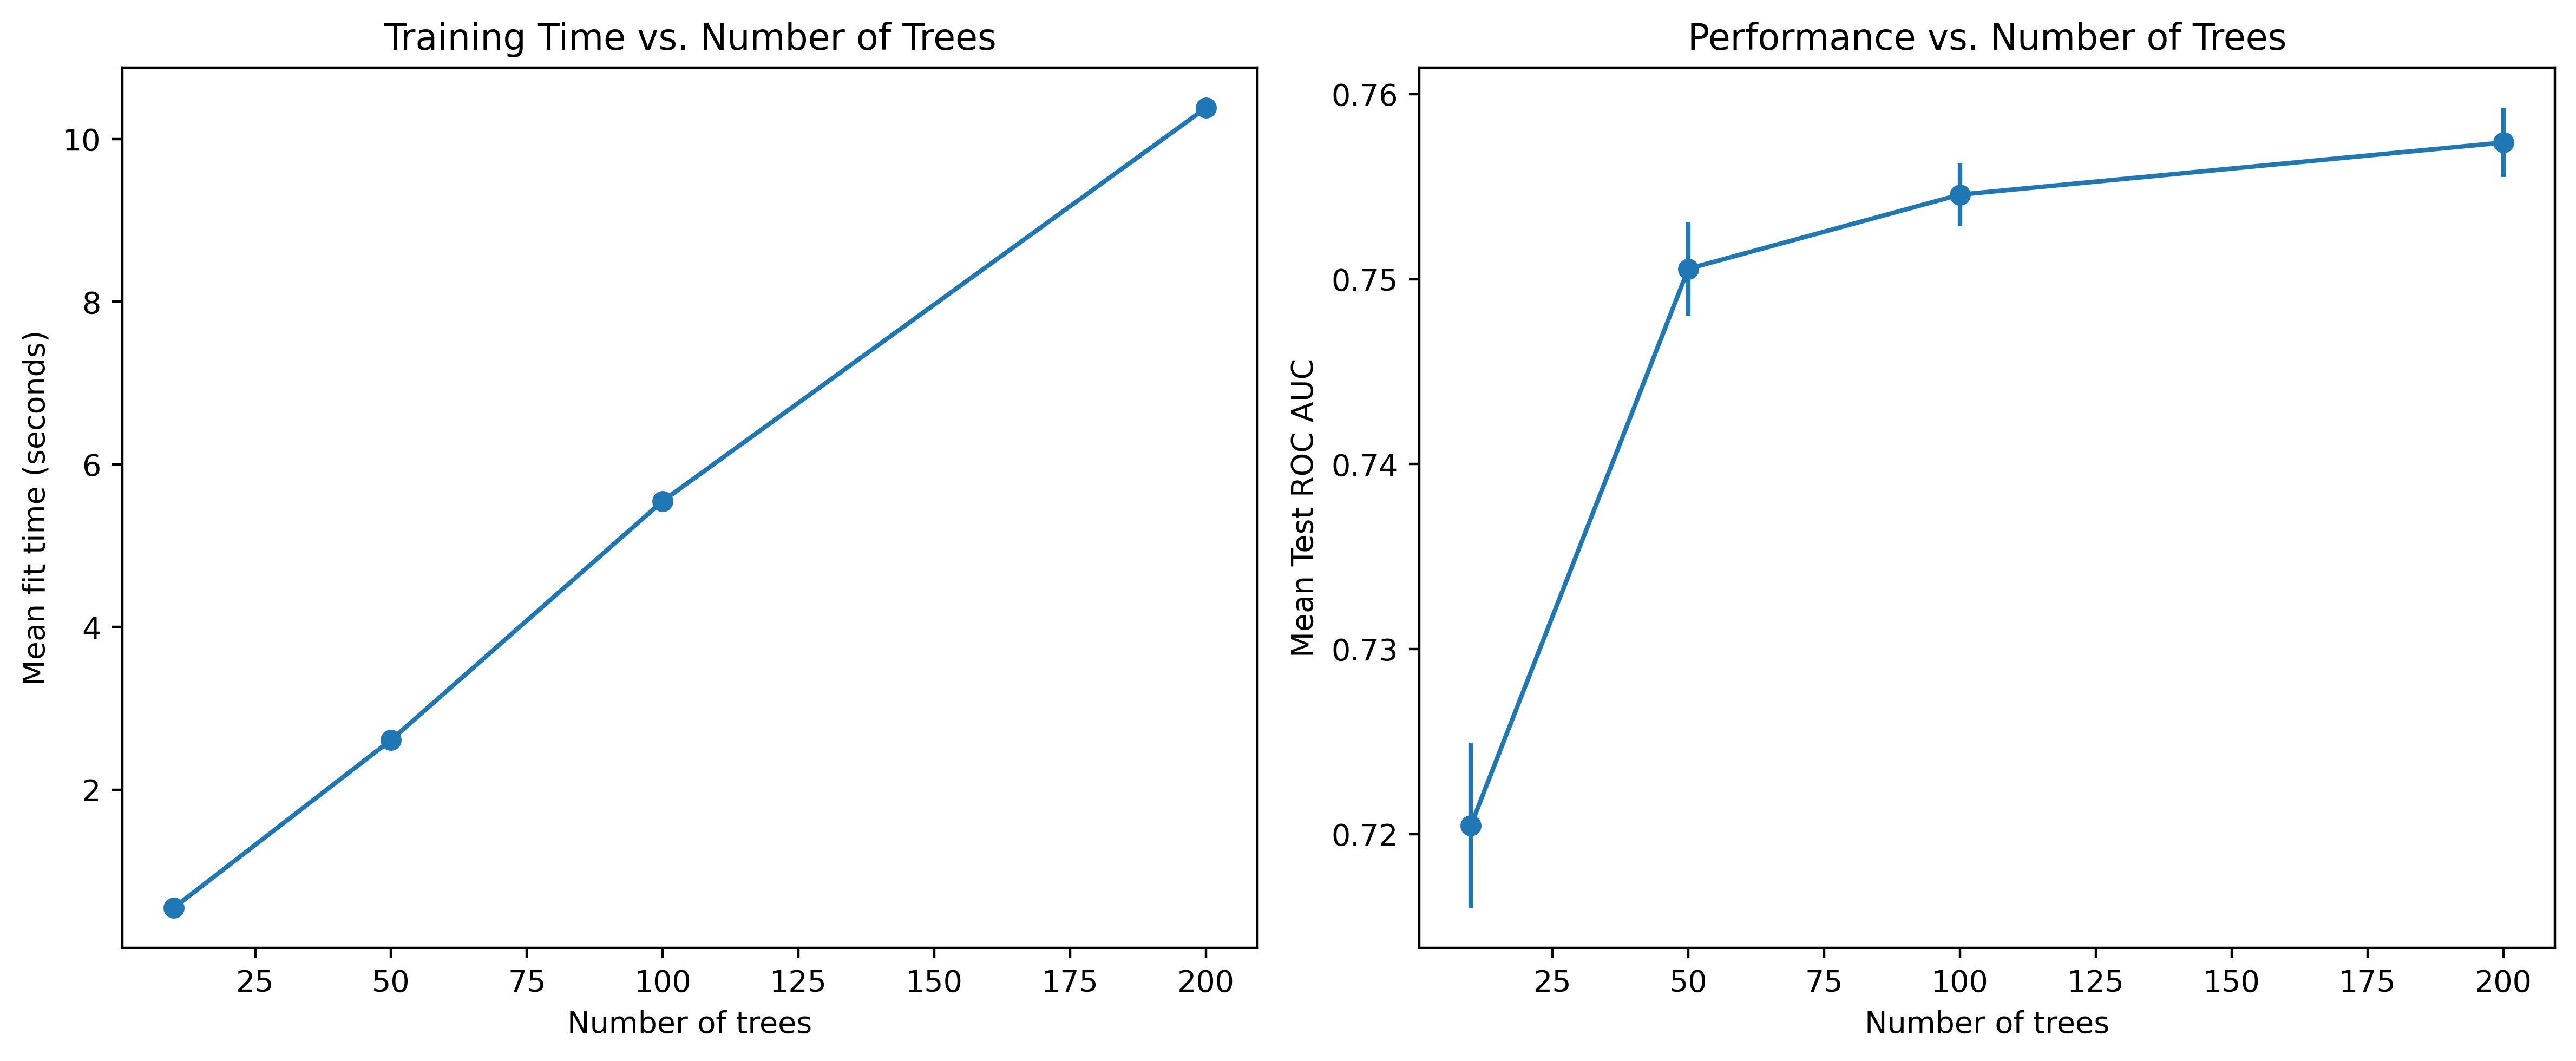

In [30]:
# Chuyển kết quả thành DataFrame
cv_rf_results_df = pd.DataFrame(cv_rf.cv_results_)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Biểu đồ thời gian huấn luyện
axs[0].plot(cv_rf_results_df['param_n_estimators'], cv_rf_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Training Time vs. Number of Trees')

# Biểu đồ điểm số (Test score với error bar)
axs[1].errorbar(
    cv_rf_results_df['param_n_estimators'], 
    cv_rf_results_df['mean_test_score'], 
    yerr=cv_rf_results_df['std_test_score'], 
    fmt='-o'
)
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean Test ROC AUC')
axs[1].set_title('Performance vs. Number of Trees')

plt.tight_layout()
plt.show()